In [1]:
import pandas as pd

df = pd.read_csv("pbl_dataset.csv")
print(df.head())

   SNo  Age  Gender  Income     Employment  LoanAmount  LoanTerm  \
0    1   26    Male  320000       Salaried      100000        24   
1    2   42  Female  780000  Self-employed      280000        36   
2    3   35    Male  520000       Salaried      200000        48   
3    4   30  Female  460000       Salaried      150000        36   
4    5   51    Male  920000       Business      400000        60   

   InterestRate  CreditScore   DTI  PastDefaults  NumLoans   Savings      EMI  \
0          10.2        720.0  0.25             0         1   50000.0   4500.0   
1          12.1        670.0  0.37             1         2  140000.0   9800.0   
2          11.0        600.0  0.46             2         3   80000.0   6200.0   
3          10.0          NaN  0.30             0         1   60000.0   4800.0   
4          13.5        560.0  0.55             3         4  200000.0  12500.0   

   Default  
0        0  
1        0  
2        1  
3        0  
4        1  


In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SNo           100 non-null    int64  
 1   Age           100 non-null    int64  
 2   Gender        100 non-null    str    
 3   Income        100 non-null    int64  
 4   Employment    100 non-null    str    
 5   LoanAmount    100 non-null    int64  
 6   LoanTerm      100 non-null    int64  
 7   InterestRate  100 non-null    float64
 8   CreditScore   96 non-null     float64
 9   DTI           97 non-null     float64
 10  PastDefaults  100 non-null    int64  
 11  NumLoans      100 non-null    int64  
 12  Savings       97 non-null     float64
 13  EMI           97 non-null     float64
 14  Default       100 non-null    int64  
dtypes: float64(5), int64(8), str(2)
memory usage: 11.8 KB
None
              SNo         Age        Income     LoanAmount    LoanTerm  \
count  100.000000  100.000000  1.00000

In [3]:
df = df.ffill()

In [4]:
df['Employment']=df['Employment'].str.replace('-','')
df['Employment']=df['Employment'].str.strip()

In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Employment']=le.fit_transform(df['Employment'])

In [6]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(df[['Employment']])

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numerical_cols = ['Age', 'Income', 'LoanAmount', 'LoanTerm',
                  'InterestRate', 'CreditScore', 'DTI',
                  'Savings', 'EMI']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

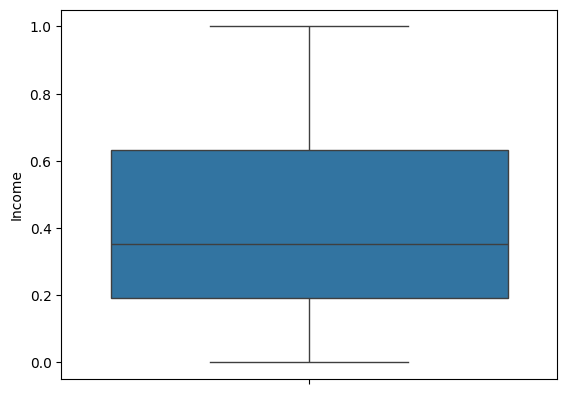

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df['Income'])
plt.show()

In [13]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Income'] >= Q1 - 1.5*IQR) & (df['Income'] <= Q3 + 1.5*IQR)]

In [14]:
df.to_csv("processed_dataset.csv",index=False)